In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

df = pd.read_csv("mobile_data1.csv")

display(df.head())
df.info()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0.0,2.2,0.0,1.0,0.0,7.0,0.6,188.0,2.0,...,20.0,756,2549.0,9.0,7.0,19.0,0.0,0.0,1.0,1
1,1021,1.0,0.5,1.0,0.0,1.0,53.0,0.7,136.0,3.0,...,905.0,1988,2631.0,17.0,3.0,7.0,1.0,1.0,0.0,2
2,563,1.0,0.5,1.0,2.0,1.0,41.0,0.9,145.0,5.0,...,1263.0,1716,2603.0,11.0,2.0,9.0,1.0,1.0,0.0,2
3,615,1.0,2.5,0.0,0.0,0.0,10.0,0.8,131.0,6.0,...,1216.0,1786,2769.0,16.0,8.0,11.0,1.0,0.0,0.0,2
4,1821,1.0,1.2,0.0,13.0,1.0,44.0,0.6,141.0,2.0,...,1208.0,1212,1411.0,8.0,2.0,15.0,1.0,1.0,0.0,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           1997 non-null   float64
 2   clock_speed    1998 non-null   float64
 3   dual_sim       1996 non-null   float64
 4   fc             1999 non-null   float64
 5   four_g         1999 non-null   float64
 6   int_memory     1997 non-null   float64
 7   m_dep          1998 non-null   float64
 8   mobile_wt      1998 non-null   float64
 9   n_cores        1997 non-null   float64
 10  pc             2000 non-null   int64  
 11  px_height      1997 non-null   float64
 12  px_width       2000 non-null   int64  
 13  ram            1998 non-null   float64
 14  sc_h           1996 non-null   float64
 15  sc_w           1999 non-null   float64
 16  talk_time      1999 non-null   float64
 17  three_g        1996 non-null   float64
 18  touch_sc

In [ ]:
# Step 1: Count missing values in each column

missing_per_column = df.isna().sum()

print("Missing values per column:")
print(missing_per_column)


# Step 2: Count how many columns contain missing values

columns_with_missing = 0

for value in missing_per_column:

    # If this column has at least one missing value,
    # add 1 to the counter.

    # YOUR CODE HERE
 Value > 0
 columns_with_missing = columns_with_missing + 1


print(
    "Number of columns with missing values:",
    columns_with_missing
)

Why should we inspect missing value before building classifciation models?

If the missingness isn't random connected with the goal or a demographic group, simple ways is to removing rows or mean-imputing can bias the model or misrepresent actual relationships in the data. Missing values can also cause many classifiers to fail completely or be silently mistreated. Instead of allowing a default action make the decision for you, inspecting first allows you to select the appropriate handling strategy.

In [ ]:
df["screen_area"] = df["sc_h"] * df["sc_w"]

display(
    df[["sc_h", "sc_w", "screen_area"]].head()
)

,sc_h,sc_w,screen_area
0,9.0,7.0,63.0
1,17.0,3.0,51.0
2,11.0,2.0,22.0
3,16.0,8.0,128.0
4,8.0,2.0,16.0


In [ ]:
 #HINT:
df.rename(
     columns={"mobile_wt": "weight"},
    inplace=True
 )

df.rename(columns={"mobile_wt": "weight"}, inplace=True)



# 2. Create pixel_area

df["pixel_area"] = df["px_height"] * df["px_width"]


# 3. Display px_height, px_width, and pixel_area

df[["px_height", "px_width", "pixel_area"]].head()

,px_height,px_width,pixel_area
0,20.0,756,15120.0
1,905.0,1988,1799140.0
2,1263.0,1716,2167308.0
3,1216.0,1786,2171776.0
4,1208.0,1212,1464096.0


In [ ]:
target_col = "price_range"

for column in df.columns:

    if column != target_col:

        # Step 1: Find the median of this column
        median_value = df[column].median()

        # Step 2: Replace missing values with the median
        # YOUR CODE HERE
        df[column] =df[column].fillna(median_value)

In [ ]:
print("Missing values after filling:")
print(df.isna().sum())

Missing values after filling:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
weight           0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
screen_area      0
pixel_area       0
dtype: int64


Why do we skip price_range when filling missing values?
Since price_range is the target or label column rather than a feature, imputing it would mean setting up labels for your model to learn from, which enhances training with fake values. The typical procedure is to drop or hold out a row if price_range is lacking instead of filling it in. -RJ



In [ ]:
X = df.drop(columns=["price_range"])
y = df["price_range"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 22)
y shape: (2000,)


In [ ]:
# 1. Count missing values in y

print(y.isna().sum())

# 2. Show the number of observations in each class

print(y.value_counts())



0
price_range
1    500
2    500
3    500
0    500
Name: count, dtype: int64


In [ ]:
class_proportions = y.value_counts(
    normalize=True
).sort_index()

print(class_proportions)

price_range
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64


are the four classes approximately balanced? Yes - RJ

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))

Training observations: 1400
Test observations: 600


In [ ]:
print("Training class proportions:")
print(
    y_train.value_counts(
        normalize=True
    ).sort_index()
)

print("\nTest class proportions:")
print(
    y_test.value_counts(
        normalize=True
    ).sort_index()
)

Training class proportions:
price_range
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64

Test class proportions:
price_range
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64


In [ ]:
# Step 1: Create the model

clf = DecisionTreeClassifier(
    random_state=42
)


# Step 2: Train the model
# HINT: clf.fit(X_train, y_train)

# YOUR CODE HERE
clf.fit(X_train, y_train)

# Step 3: Predict the test data
# HINT: clf.predict(X_test)

# YOUR CODE HERE
y_pred = clf.predict(X_test)


In [ ]:
y_test

,price_range
570,3
414,3
1837,1
1510,1
1130,3
...,...
544,1
1303,3
1193,0
1818,0


In [ ]:
accuracy = accuracy_score(y_test,y_pred)

print("Test Accuracy:",round(accuracy, 4))

Test Accuracy: 0.845


In [ ]:
# Step 1: Create a smaller decision tree

clf_small = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)


# Step 2: Train the smaller tree

clf_small.fit(X_train, y_train)




DecisionTreeClassifier(max_depth=3, random_state=42)

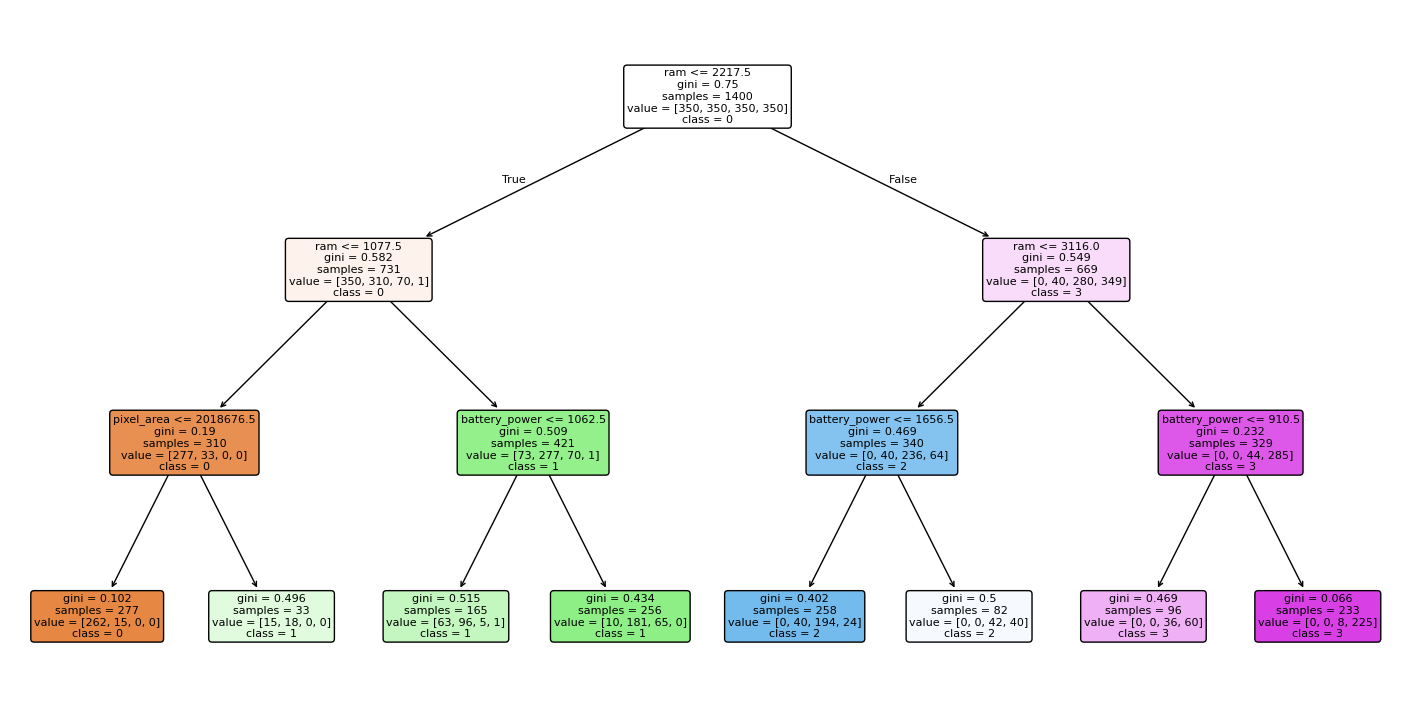

In [ ]:
plt.figure(figsize=(18, 9))

plot_tree(
    clf_small,
    feature_names=X.columns,
    class_names=[
        str(c) for c in sorted(y.unique())
    ],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

In [ ]:
Which feature is used at the root node? Ram -RJ
What condition is used for the first spilt? Ram <= 2217.5 - RJ
Why is the depth 3-tree easier to interpret than a fully grown tree?
While a fully grown tree can include dozens of nested splits that are difficult for a person to understand, a depth-3 tree limits each forecast to just three yes/no questions, allowing you to trace and explain the entire decision route at a look.-RJ

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    clf,
    X,
    y,
    cv=cv,
    scoring="accuracy"
)

print("Accuracy for each fold:")
print(cv_scores)

print(
    "\nMean CV Accuracy:",
    round(cv_scores.mean(), 4)
)


Accuracy for each fold:
[0.8675 0.8475 0.825  0.855  0.855 ]

Mean CV Accuracy: 0.85


In [ ]:
results = []

for d in [2, 3, 4, 5, 6]:

    # Step 1: Create a tree using this depth

    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42
    )


    # Step 2: Calculate CV scores for this model

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring="accuracy"
    )


    # Step 3: Calculate the mean accuracy

    mean_accuracy = scores.mean()


    # Step 4: Save the depth and mean accuracy
    # HINT:
    results.append((d, mean_accuracy))



In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "max_depth",
        "cv_accuracy"
    ]
)

display(results_df)

,max_depth,cv_accuracy
0,2,0.7495
1,3,0.7435
2,4,0.7915
3,5,0.8220
4,6,0.8395


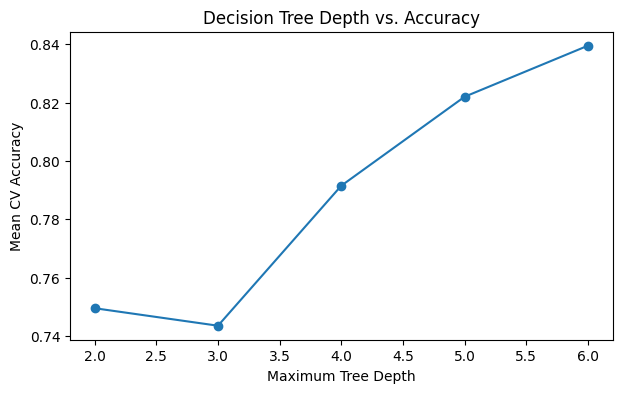

In [ ]:
plt.figure(figsize=(7, 4))

plt.plot(
    results_df["max_depth"],
    results_df["cv_accuracy"],
    marker="o"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Mean CV Accuracy")
plt.title("Decision Tree Depth vs. Accuracy")

plt.show()

which tested tree depth gives the highest cross validation accuracy? Depth 6 has the highest Cross Vaildation accuracy. -RJ

Does a deeper tree always perform better? No it not always the case. -RJ

why might an extremely deep tree perform poorly on new data?

A very deep tree continues to split until its leaves suit individual outliers or noise rather than the true underlying pattern due to minute, particular peculiarities of the training data. - RJ

which tested tree depth gives the highest cross validation accuracy? price_range -RJ

why do we evaluate a model using data that were not used for training? A model can memorize its training data and appear to do very well on that data, but you only know if it has learnt a generalizable pattern if you test it on unknown data.-RJ

 Based on the cross vaildation results, what max_depth would you choose? why? I would  choose depth 6, since it produced the highest mean cross-validation accuracy (~0.84) among the depths tested.


